# Pengaturan Awal & Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_selection import mutual_info_classif, SelectKBest, chi2, f_classif

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
import joblib
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV, RandomizedSearchCV

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, VotingClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

from sklearn.metrics import roc_auc_score, roc_curve, classification_report, precision_score, recall_score, f1_score, precision_recall_curve


import warnings
warnings.filterwarnings("ignore")


In [2]:
df = pd.read_csv('../training_dataset.csv')
df

,customer_number,usia,pekerjaan,status_perkawinan,pendidikan,gagal_bayar_sebelumnya,pinjaman_rumah,pinjaman_pribadi,jenis_kontak,bulan_kontak_terakhir,...,hari_sejak_kontak_sebelumnya,jumlah_kontak_sebelumnya,hasil_kampanye_sebelumnya,tingkat_variasi_pekerjaan,indeks_harga_konsumen,indeks_kepercayaan_konsumen,suku_bunga_euribor_3bln,jumlah_pekerja,pulau,berlangganan_deposito
0,531036,63,sosial media specialis,menikah,Pendidikan Tinggi,no,yes,no,cellular,jul,...,999,0,nonexistent,-1.7,94.215,-40.3,0.885,4991.6,Papua,1
1,999241,43,teknisi,menikah,Pendidikan Tinggi,no,yes,no,cellular,nov,...,999,0,nonexistent,-0.1,93.200,-42.0,4.021,5195.8,Sulawesi,0
2,995002,29,sosial media specialis,lajang,Pendidikan Tinggi,no,yes,yes,cellular,jul,...,999,0,nonexistent,1.4,93.918,-42.7,4.958,5228.1,Papua,0
3,932750,40,pekerja kasar,menikah,SMA,no,no,no,telephone,may,...,999,0,nonexistent,1.1,93.994,-36.4,4.859,5191.0,Sumatera,1
4,684699,40,sosial media specialis,lajang,Pendidikan Tinggi,no,no,no,cellular,aug,...,999,0,nonexistent,1.4,93.444,-36.1,4.964,5228.1,Bali,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22911,680377,32,teknisi,menikah,Diploma,no,yes,no,cellular,aug,...,999,0,nonexistent,1.4,93.444,-36.1,4.967,5228.1,Kalimantan,0
22912,505429,30,mahasiswa,lajang,Diploma,no,no,no,telephone,sep,...,999,0,nonexistent,-1.1,94.199,-37.5,0.880,4963.6,Bali,0
22913,308952,29,manajer,lajang,SMA,no,yes,no,cellular,jul,...,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,NTT,0
22914,865813,52,entrepreneur,menikah,Tidak Tamat SD,unknown,yes,no,telephone,jun,...,999,0,nonexistent,1.4,94.465,-41.8,4.960,5228.1,NTB,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22916 entries, 0 to 22915
Data columns (total 22 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   customer_number               22916 non-null  int64  
 1   usia                          22916 non-null  int64  
 2   pekerjaan                     22916 non-null  object 
 3   status_perkawinan             22916 non-null  object 
 4   pendidikan                    22916 non-null  object 
 5   gagal_bayar_sebelumnya        22916 non-null  object 
 6   pinjaman_rumah                22916 non-null  object 
 7   pinjaman_pribadi              22916 non-null  object 
 8   jenis_kontak                  22916 non-null  object 
 9   bulan_kontak_terakhir         22916 non-null  object 
 10  hari_kontak_terakhir          22916 non-null  object 
 11  jumlah_kontak_kampanye_ini    22916 non-null  int64  
 12  hari_sejak_kontak_sebelumnya  22916 non-null  int64  
 13  j

In [4]:
df.describe(include='all')

,customer_number,usia,pekerjaan,status_perkawinan,pendidikan,gagal_bayar_sebelumnya,pinjaman_rumah,pinjaman_pribadi,jenis_kontak,bulan_kontak_terakhir,...,hari_sejak_kontak_sebelumnya,jumlah_kontak_sebelumnya,hasil_kampanye_sebelumnya,tingkat_variasi_pekerjaan,indeks_harga_konsumen,indeks_kepercayaan_konsumen,suku_bunga_euribor_3bln,jumlah_pekerja,pulau,berlangganan_deposito
count,22916.000000,22916.000000,22916,22916,22916,22916,22916,22916,22916,22916,...,22916.000000,22916.000000,22916,22916.000000,22916.000000,22916.000000,22916.000000,22916.000000,22916,22916.000000
unique,NaN,NaN,12,4,8,3,3,3,2,10,...,NaN,NaN,3,NaN,NaN,NaN,NaN,NaN,8,NaN
top,NaN,NaN,sosial media specialis,menikah,Pendidikan Tinggi,no,yes,no,cellular,may,...,NaN,NaN,nonexistent,NaN,NaN,NaN,NaN,NaN,Jawa,NaN
freq,NaN,NaN,5755,13858,6699,18169,12053,18888,14523,7611,...,NaN,NaN,19836,NaN,NaN,NaN,NaN,NaN,2973,NaN
mean,550930.993193,40.016233,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,962.210377,0.170143,NaN,0.077915,93.576541,-40.485717,3.617890,5166.773124,NaN,0.114069
std,259909.889175,10.438059,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,187.566774,0.490611,NaN,1.576176,0.580586,4.641091,1.737591,72.479698,NaN,0.317902
min,100108.000000,17.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000000,0.000000,NaN,-3.400000,92.201000,-50.800000,0.634000,4963.600000,NaN,0.000000
25%,325755.000000,32.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,999.000000,0.000000,NaN,-1.800000,93.075000,-42.700000,1.344000,5099.100000,NaN,0.000000
50%,553139.000000,38.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,999.000000,0.000000,NaN,1.100000,93.876000,-41.800000,4.857000,5191.000000,NaN,0.000000
75%,777157.500000,47.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,999.000000,0.000000,NaN,1.400000,93.994000,-36.400000,4.961000,5228.100000,NaN,0.000000


In [5]:
df_validation = pd.read_csv('../validation_set.csv')
df_validation

,customer_number,usia,pekerjaan,status_perkawinan,pendidikan,gagal_bayar_sebelumnya,pinjaman_rumah,pinjaman_pribadi,jenis_kontak,bulan_kontak_terakhir,...,jumlah_kontak_kampanye_ini,hari_sejak_kontak_sebelumnya,jumlah_kontak_sebelumnya,hasil_kampanye_sebelumnya,tingkat_variasi_pekerjaan,indeks_harga_konsumen,indeks_kepercayaan_konsumen,suku_bunga_euribor_3bln,jumlah_pekerja,pulau
0,445420,35,penyedia jasa,menikah,SMA,no,yes,yes,cellular,jul,...,1,999,0,nonexistent,1.4,93.918,-42.7,4.960,5228.1,Jawa
1,585604,52,teknisi,lajang,Diploma,unknown,no,no,telephone,may,...,4,999,0,nonexistent,1.1,93.994,-36.4,4.860,5191.0,Papua
2,888824,37,pekerja kasar,menikah,SMP,unknown,yes,no,telephone,may,...,3,999,0,nonexistent,1.1,93.994,-36.4,4.856,5191.0,Bali
3,816820,51,pengangguran,menikah,Diploma,no,no,no,telephone,may,...,3,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,Sumatera
4,542716,45,teknisi,cerai,SMA,no,yes,no,cellular,may,...,1,999,1,failure,-1.8,92.893,-46.2,1.327,5099.1,Sumatera
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5724,782072,51,pekerja kasar,menikah,Tidak Tamat SD,no,yes,no,telephone,jun,...,1,999,0,nonexistent,1.4,94.465,-41.8,4.961,5228.1,Kalimantan
5725,116371,30,pekerja kasar,menikah,SMP,no,yes,yes,telephone,may,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,Sulawesi
5726,773759,45,pekerja kasar,menikah,SMP,unknown,yes,no,telephone,may,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,NTB
5727,612330,60,teknisi,menikah,Diploma,unknown,no,no,telephone,jul,...,15,999,0,nonexistent,1.4,93.918,-42.7,4.961,5228.1,Papua


In [6]:
df_validation.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5729 entries, 0 to 5728
Data columns (total 21 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   customer_number               5729 non-null   int64  
 1   usia                          5729 non-null   int64  
 2   pekerjaan                     5729 non-null   object 
 3   status_perkawinan             5729 non-null   object 
 4   pendidikan                    5729 non-null   object 
 5   gagal_bayar_sebelumnya        5729 non-null   object 
 6   pinjaman_rumah                5729 non-null   object 
 7   pinjaman_pribadi              5729 non-null   object 
 8   jenis_kontak                  5729 non-null   object 
 9   bulan_kontak_terakhir         5729 non-null   object 
 10  hari_kontak_terakhir          5729 non-null   object 
 11  jumlah_kontak_kampanye_ini    5729 non-null   int64  
 12  hari_sejak_kontak_sebelumnya  5729 non-null   int64  
 13  jum

In [7]:
df_validation.describe(include='all')

,customer_number,usia,pekerjaan,status_perkawinan,pendidikan,gagal_bayar_sebelumnya,pinjaman_rumah,pinjaman_pribadi,jenis_kontak,bulan_kontak_terakhir,...,jumlah_kontak_kampanye_ini,hari_sejak_kontak_sebelumnya,jumlah_kontak_sebelumnya,hasil_kampanye_sebelumnya,tingkat_variasi_pekerjaan,indeks_harga_konsumen,indeks_kepercayaan_konsumen,suku_bunga_euribor_3bln,jumlah_pekerja,pulau
count,5729.000000,5729.000000,5729,5729,5729,5729,5729,5729,5729,5729,...,5729.000000,5729.000000,5729.000000,5729,5729.000000,5729.000000,5729.000000,5729.000000,5729.000000,5729
unique,NaN,NaN,12,4,8,2,3,3,2,10,...,NaN,NaN,NaN,3,NaN,NaN,NaN,NaN,NaN,8
top,NaN,NaN,sosial media specialis,menikah,Pendidikan Tinggi,no,yes,no,cellular,may,...,NaN,NaN,NaN,nonexistent,NaN,NaN,NaN,NaN,NaN,Sulawesi
freq,NaN,NaN,1458,3503,1732,4522,2960,4725,3667,1941,...,NaN,NaN,NaN,4988,NaN,NaN,NaN,NaN,NaN,748
mean,548493.630826,39.852679,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.545470,964.329377,0.162157,NaN,0.096003,93.571413,-40.471356,3.638297,5167.914662,NaN
std,258992.541542,10.348971,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.618704,182.310129,0.471306,NaN,1.565580,0.576929,4.632091,1.727321,71.802171,NaN
min,100423.000000,18.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.000000,0.000000,0.000000,NaN,-3.400000,92.201000,-50.800000,0.634000,4963.600000,NaN
25%,323527.000000,32.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.000000,999.000000,0.000000,NaN,-1.800000,93.075000,-42.700000,1.344000,5099.100000,NaN
50%,552893.000000,38.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.000000,999.000000,0.000000,NaN,1.100000,93.444000,-41.800000,4.857000,5191.000000,NaN
75%,772131.000000,46.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3.000000,999.000000,0.000000,NaN,1.400000,93.994000,-36.400000,4.961000,5228.100000,NaN


# Exploratory Data Analysis

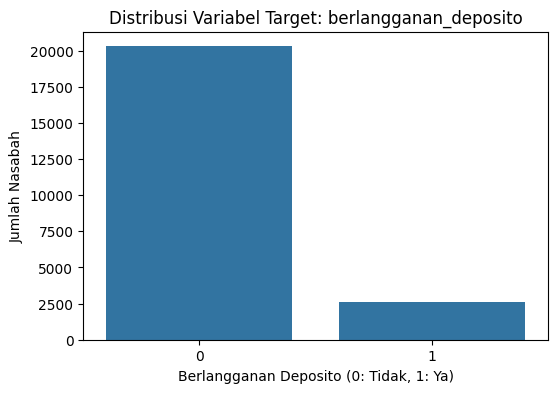

berlangganan_deposito
0    0.885931
1    0.114069
Name: proportion, dtype: float64
Terlihat jelas adanya ketidakseimbangan kelas (imbalanced class).


In [8]:
plt.figure(figsize=(6, 4))
sns.countplot(x='berlangganan_deposito', data=df)
plt.title('Distribusi Variabel Target: berlangganan_deposito')
plt.xlabel('Berlangganan Deposito (0: Tidak, 1: Ya)')
plt.ylabel('Jumlah Nasabah')
plt.show()
print(df['berlangganan_deposito'].value_counts(normalize=True))
print("Terlihat jelas adanya ketidakseimbangan kelas (imbalanced class).")

In [9]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
numeric_cols.remove('customer_number') # Remove customer_number from analysis
numeric_cols.remove('berlangganan_deposito') # Remove target from features for distribution analysis

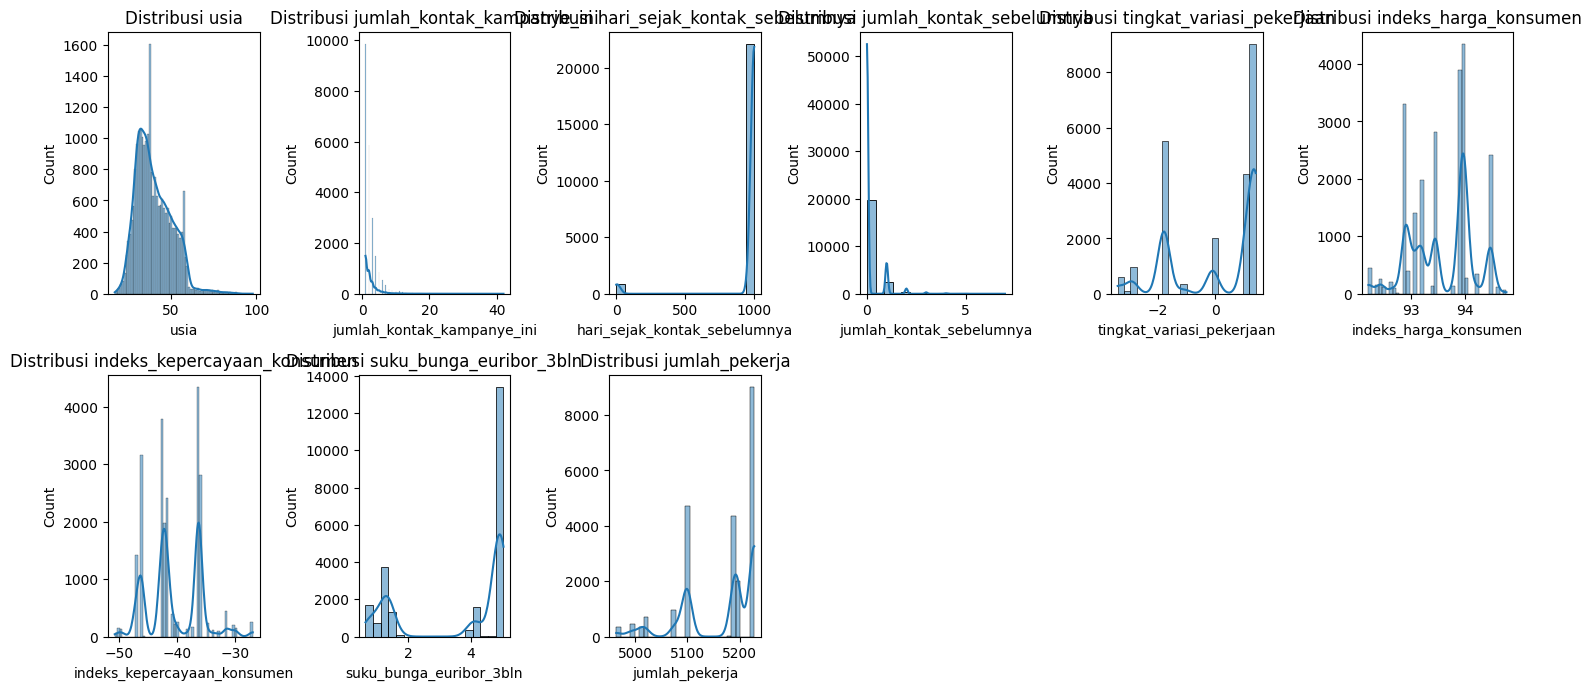

In [10]:
plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric_cols):
    plt.subplot(3, 6, i + 1)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribusi {col}')
    plt.tight_layout()
plt.show()

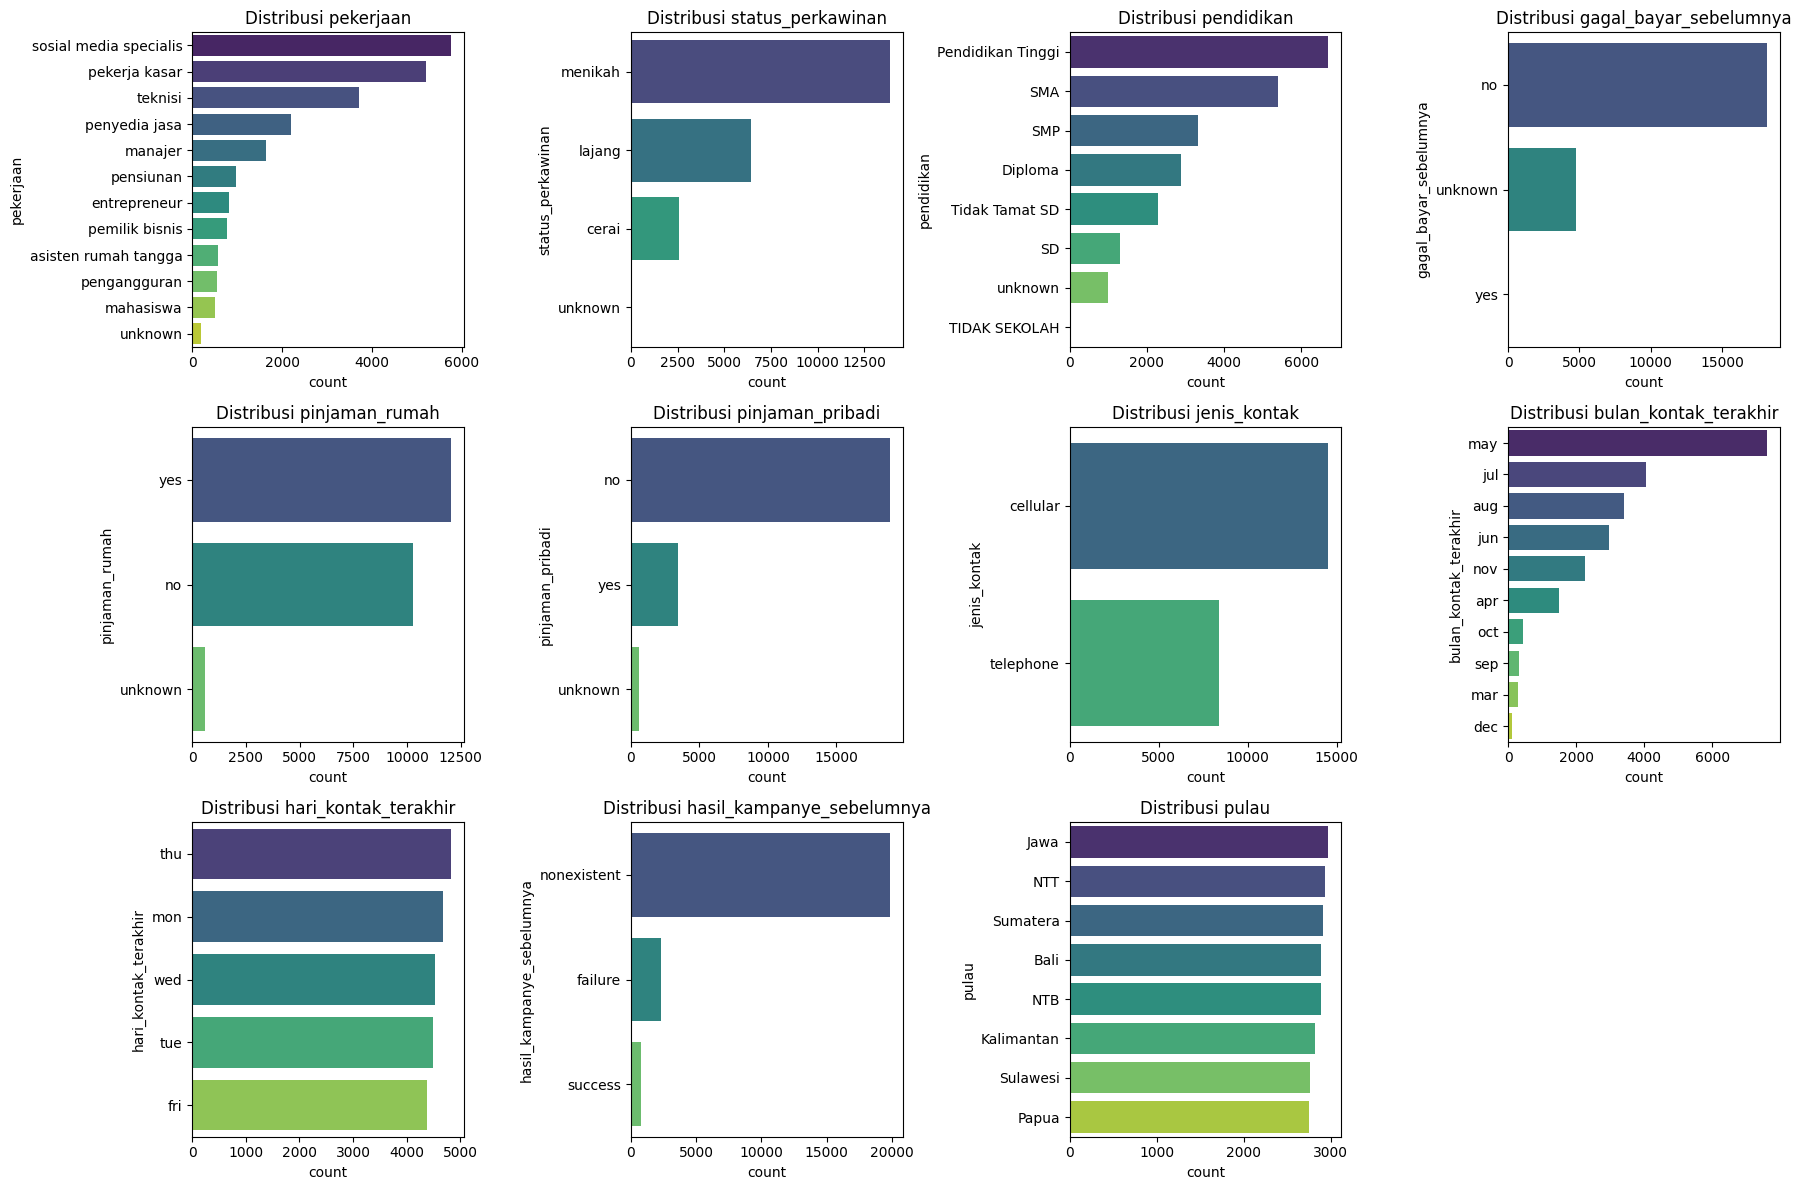

In [11]:
categorical_cols = df.select_dtypes(include='object').columns.tolist()

plt.figure(figsize=(18, 12))
for i, col in enumerate(categorical_cols):
    plt.subplot(3, 4, i + 1)
    sns.countplot(y=df[col], order=df[col].value_counts().index, palette='viridis')
    plt.title(f'Distribusi {col}')
    plt.tight_layout()
plt.show()

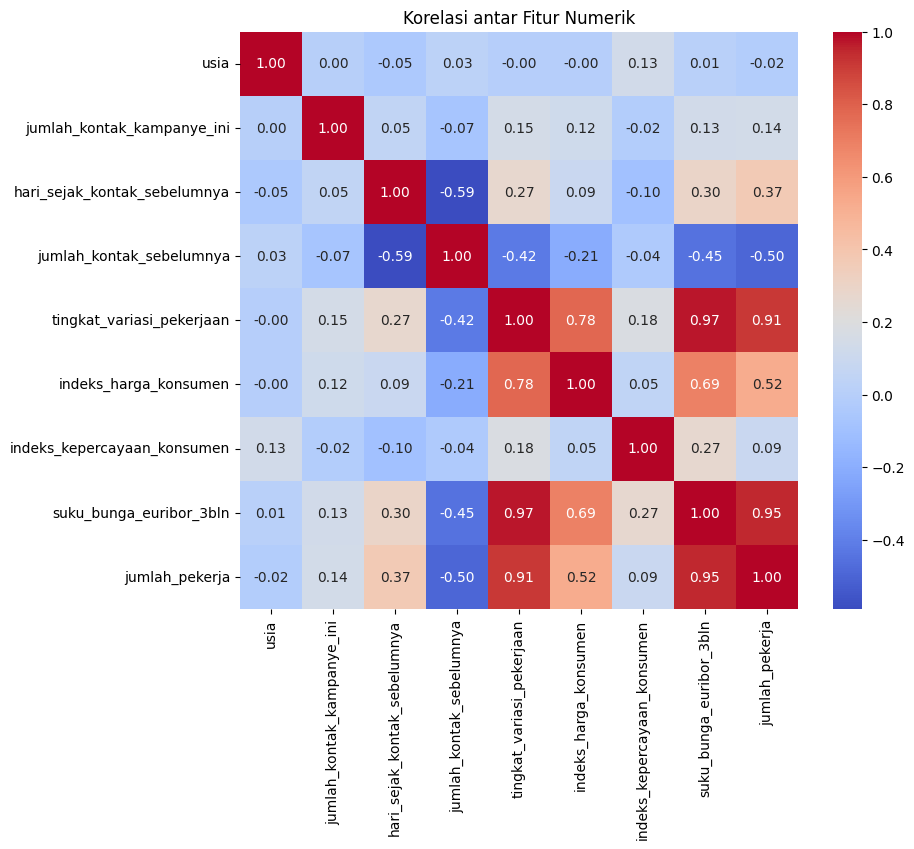

In [12]:
plt.figure(figsize=(9, 7.5))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Korelasi antar Fitur Numerik')
plt.show()

EDA Selesai. Insight:

- Distribusi target sangat tidak seimbang
- Kolom 'hari_sejak_kontak_sebelumnya' didominasi oleh nilai 999, mengindikasikan tidak ada kontak sebelumnya
- Beberapa kolom kategorikal memiliki nilai 'unknown'
- Beberapa fitur numerik menunjukkan skewness atau distribusi yang tidak normal.


# Strategi untuk kedepannya

## Sisi Preprocessing dan EDA

Aku punya asumsi dan pikiran bahwa mungkin fitur-fitur yang berhubungan dengan kontak antara customer dengan kita itu tidak diperlukan atau mungkin tidak semuanya dibutuhkan, dimana mengingat kalau kita mau memprediksi **JAUH SEBELEUM SI CUSTOMER TERSEBUT DIHUBUNGI**.

Itu jadi *game-changer* karena secara eksplisit mengindikasikan adanya data leakage atau setidaknya **mismatched business objective** jika kita menggunakan fitur-fitur yang hanya diketahui setelah kontak dilakukan.

Fitur-fitur yang Bermasalah (potensi data leakage/tidak relevan untuk prediksi "*sebelum kontak*"):

* `jenis_kontak` (`contact`): Ini jelas hanya ada setelah dihubungi, yaa logikanya gimana mau tau jenis kontak kalo ga dihubungi dulu 😹.
* `bulan_kontak_terakhir` (`month`): Bulan saat kontak terakhir terjadi. Sama hanya ada setelah dihubungi.
* `hari_kontak_terakhir` (`day_of_week`): Hari saat kontak terakhir terjadi. Sama hanya ada setelah dihubungi.
* `jumlah_kontak_kampanye_ini` (`campaign`): Jumlah kontak selama kampanye ini. Jelas hanya ada setelah kampanye dimulai dan kontak terjadi.
* `hari_sejak_kontak_sebelumnya` (`pdays`): Jumlah hari sejak kontak terakhir dari kampanye sebelumnya. Ini juga mengacu pada sejarah kontak, jadi informasi ini baru ada setelah ada kontak sebelumnya. Nilai 999 (belum pernah dihubungi) memang bisa kita gunakan, tetapi informasi spesifik lainnya (<999) baru ada setelah dihubungi.
* `jumlah_kontak_sebelumnya` (`previous`): Jumlah kontak sebelum kampanye ini. Sama seperti pdays, ini adalah hasil dari riwayat kontak.
* `hasil_kampanye_sebelumnya` (`poutcome`): Hasil kampanye sebelumnya. Ini adalah hasil dari kontak yang sudah terjadi.

**Kita harus menghapus atau merekayasa fitur-fitur yang hanya diketahui setelah kontak dilakukan, atau setidaknya membatasinya pada informasi yang sudah tersedia sebelum kontak pertama di kampanye baru.**

**Strategi Pemilihan Fitur Baru** <br>
Untuk kolom-kolom yang bermasalah, kita bisa melakukan:
* Hapus Total, hehe.
* tambah beberapa kolom/fitur yang berpotensi

## Modeling

Lalu untuk dari sisi model, aku berfikir bagaimana jika kita menggunakan model-model dasar seperti `RandomForest`, `DecisionTree`, `SVM`, atau model-model lainnya untuk menjadi model base. Tapi perlu diingat kalau kita memilih model bukan karena dari nilai ROC AUC nya saja, tapi kita harus melihat precision dan recall nya juga. Lalu kita ensemble semua model tersebut dengan menggunakan `VotingClassifier` dengan settingan soft karena kita menginginkan hasil probability.

Nah dengan perubahan yang udah ada pada strategi di sisi preprocessing dan EDA, model kita akan menjadi less powerful dalam hal AUC absolut, karena kita menghilangkan fitur yang sangat prediktif (tapi bocor/tidak sesuai tujuan bisnis). Namun, model ini akan jauh lebih berguna dan relevan untuk tujuan bisnis yang sebenarnya: **memprediksi potensi nasabah tanpa perlu mengintervensi mereka terlebih dahulu**. Ini adalah trade-off yang perlu diterima dalam kompetisi yang menekankan business utility, karena ini lah hasil yang sesuai dengan asumsi tujuan kita di awal.

Untuk Model Base kita gunakan `RandomForest`, `XGBoost`, `LightGBM`, `Logistic Regression` sebagai model dasar. Kita tidak akan gunakan DecisionTree tunggal karena harus membatasi kedalamannya secara ekstrim, karena ia kurang stabil. Dan karena kita (lebih tepatnya aku sebagai data scientist di sini 🗿) malas.

Untuk Hyperparameter Tuning kita gunakan Optuna untuk tuning setiap model dasar secara individual dengan target AUC. **DAN INGAT** untuk menggunakan scale_pos_weight untuk XGBoost/LightGBM.

Terus Ensembling kita gunakan VotingClassifier(voting='soft') untuk menggabungkan prediksi probabilitas mereka, tapi tiap moddel harus di tuning dulu.

Dan yang terakhir... evaluasi~. Selain ROC AUC, kita diskusikan precision dan recall untuk kelas 1 (berlangganan_deposito) pada test set, dan rekomendasikan penyesuaian threshold jika perlu sesuai konteks bisnis meskipun sepertinya tidak perlu juga.

# Preprocessing Data

In [13]:
columns_to_drop_for_prediction_before_contact = [
    'jenis_kontak',
    'bulan_kontak_terakhir',
    'hari_kontak_terakhir',
    'jumlah_kontak_kampanye_ini',
    'hari_sejak_kontak_sebelumnya', # Dihapus total karena info historis
    'jumlah_kontak_sebelumnya',     # Dihapus total karena info historis
    'hasil_kampanye_sebelumnya'     # Dihapus total karena info historis
]
df.drop(columns=columns_to_drop_for_prediction_before_contact, inplace=True)

In [14]:
df_validation.drop(columns=columns_to_drop_for_prediction_before_contact, inplace=True)

In [15]:
# Membuat kolom baru 'kelompok_usia' berdasarkan binning usia
bins = [17, 25, 55, np.inf]
labels = ['Nasabah muda', 'Nasabah dewasa/menengah', 'Nasabah senior/pensiunan']

df['kelompok_usia'] = pd.cut(df['usia'], bins=bins, labels=labels).astype(object)
df_validation['kelompok_usia'] = pd.cut(df_validation['usia'], bins=bins, labels=labels).astype(object)

print(df[['usia', 'kelompok_usia']])

df.drop(columns=['usia'], inplace=True)
df_validation.drop(columns=['usia'], inplace=True)

df.kelompok_usia.value_counts()

       usia             kelompok_usia
0        63  Nasabah senior/pensiunan
1        43   Nasabah dewasa/menengah
2        29   Nasabah dewasa/menengah
3        40   Nasabah dewasa/menengah
4        40   Nasabah dewasa/menengah
...     ...                       ...
22911    32   Nasabah dewasa/menengah
22912    30   Nasabah dewasa/menengah
22913    29   Nasabah dewasa/menengah
22914    52   Nasabah dewasa/menengah
22915    49   Nasabah dewasa/menengah

[22916 rows x 2 columns]


kelompok_usia
Nasabah dewasa/menengah     19976
Nasabah senior/pensiunan     1991
Nasabah muda                  946
Name: count, dtype: int64

In [16]:
df['pinjaman'] = ((df['pinjaman_rumah'] == 'yes') | (df['pinjaman_pribadi'] == 'yes')).astype(int)
df_validation['pinjaman'] = ((df_validation['pinjaman_rumah'] == 'yes') | (df_validation['pinjaman_pribadi'] == 'yes')).astype(int)

In [17]:
df['default_or_unknown'] = ((df['gagal_bayar_sebelumnya'] == 'yes') | (df['gagal_bayar_sebelumnya'] == 'unknown')).astype(int)
df_validation['default_or_unknown'] = ((df_validation['gagal_bayar_sebelumnya'] == 'yes') | (df_validation['gagal_bayar_sebelumnya'] == 'unknown')).astype(int)

In [18]:
# is_retired_and_married_high_education
df['is_retired_and_married_high_education'] = (
    (df['status_perkawinan'] == 'married') &
    (df['kelompok_usia'] == 'Nasabah senior/pensiunan') &
    ((df['pendidikan'] == 'Pendidikan Tinggi') | (df['pendidikan'] == 'Diploma'))
).astype(int)

df_validation['is_retired_and_married_high_education'] = (
    (df_validation['status_perkawinan'] == 'married') &
    (df_validation['kelompok_usia'] == 'Nasabah senior/pensiunan') &
    ((df_validation['pendidikan'] == 'Pendidikan Tinggi') | (df_validation['pendidikan'] == 'Diploma'))
).astype(int)

In [19]:
# Buat kolom baru 'interest_rate_vs_inflation' (rasio dan selisih)
df['interest_rate_vs_inflation'] = df['suku_bunga_euribor_3bln'] / (df['indeks_harga_konsumen'] + 1e-8)
df_validation['interest_rate_vs_inflation'] = df_validation['suku_bunga_euribor_3bln'] / (df_validation['indeks_harga_konsumen'] + 1e-8)

# Buat kolom baru 'economic_optimism' (produk indeks_kepercayaan_konsumen * jumlah_pekerja)
df['economic_optimism'] = df['indeks_kepercayaan_konsumen'] * df['jumlah_pekerja']
df_validation['economic_optimism'] = df_validation['indeks_kepercayaan_konsumen'] * df_validation['jumlah_pekerja']

# Binning untuk 'interest_rate_vs_inflation'
df['interest_rate_vs_inflation_bin'] = pd.qcut(df['interest_rate_vs_inflation'], q=3, labels=['low_confidence', 'medium_confidence', 'high_confidence']).astype(object)
df_validation['interest_rate_vs_inflation_bin'] = pd.qcut(df_validation['interest_rate_vs_inflation'], q=3, labels=['low_confidence', 'medium_confidence', 'high_confidence']).astype(object)

# Binning untuk 'economic_optimism'
df['economic_optimism_bin'] = pd.qcut(df['economic_optimism'], q=3, labels=['low_confidence', 'medium_confidence', 'high_confidence']).astype(object)
df_validation['economic_optimism_bin'] = pd.qcut(df_validation['economic_optimism'], q=3, labels=['low_confidence', 'medium_confidence', 'high_confidence']).astype(object)

# Cek hasil
print(df[['interest_rate_vs_inflation', 'interest_rate_vs_inflation_bin', 'economic_optimism', 'economic_optimism_bin']].head())

# drop column economic_optimism dan interest_rate_vs_inflation
df.drop(columns=['economic_optimism', 'interest_rate_vs_inflation'], inplace=True)
df_validation.drop(columns=['economic_optimism', 'interest_rate_vs_inflation'], inplace=True)

   interest_rate_vs_inflation interest_rate_vs_inflation_bin  \
0                    0.009393                 low_confidence   
1                    0.043144                 low_confidence   
2                    0.052791                high_confidence   
3                    0.051695              medium_confidence   
4                    0.053123                high_confidence   

   economic_optimism economic_optimism_bin  
0         -201161.48     medium_confidence  
1         -218223.60     medium_confidence  
2         -223239.87        low_confidence  
3         -188952.40     medium_confidence  
4         -188734.41       high_confidence  


In [20]:
X = df.drop(columns=['customer_number', 'berlangganan_deposito'])
y = df['berlangganan_deposito']

In [21]:
numerical_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(include='object').columns.tolist()

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [23]:
print(f"Ukuran X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"Ukuran X_test: {X_test.shape}, y_test: {y_test.shape}")
print("Distribusi target di training set:")
print(y_train.value_counts(normalize=True))
print("Distribusi target di test set:")
print(y_test.value_counts(normalize=True))

Ukuran X_train: (18332, 18), y_train: (18332,)
Ukuran X_test: (4584, 18), y_test: (4584,)
Distribusi target di training set:
berlangganan_deposito
0    0.885937
1    0.114063
Name: proportion, dtype: float64
Distribusi target di test set:
berlangganan_deposito
0    0.885908
1    0.114092
Name: proportion, dtype: float64


In [24]:
print(f"\nFitur Numerik yang digunakan: {numerical_features}")
print(f"Fitur Kategorikal yang digunakan: {categorical_features}")
print(f"Total Fitur yang digunakan: {len(numerical_features) + len(categorical_features)} (sebelum OneHotEncoder)")


Fitur Numerik yang digunakan: ['tingkat_variasi_pekerjaan', 'indeks_harga_konsumen', 'indeks_kepercayaan_konsumen', 'suku_bunga_euribor_3bln', 'jumlah_pekerja', 'pinjaman', 'default_or_unknown', 'is_retired_and_married_high_education']
Fitur Kategorikal yang digunakan: ['pekerjaan', 'status_perkawinan', 'pendidikan', 'gagal_bayar_sebelumnya', 'pinjaman_rumah', 'pinjaman_pribadi', 'pulau', 'kelompok_usia', 'interest_rate_vs_inflation_bin', 'economic_optimism_bin']
Total Fitur yang digunakan: 18 (sebelum OneHotEncoder)


## Penanganan Imbalanced Class

SMOTE akan diaplikasikan setelah split dan sebelum scaling/encoding, dan hanya pada training data. Best practice adalah memasukkannya ke dalam pipeline imb.


In [25]:
# scale_pos_weight untuk XGBoost dan LightGBM
neg_count = y_train.value_counts()[0]
pos_count = y_train.value_counts()[1]
scale_pos_weight_value = neg_count / pos_count
print(f"Calculated scale_pos_weight: {scale_pos_weight_value:.2f}")

Calculated scale_pos_weight: 7.77


# Model Training & Hyperparameter Tuning

In [26]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features) # handle_unknown='ignore' untuk data test baru
    ])

In [27]:
best_individual_models = {}
results_individual_tuning = []
cv_strategy_optuna = StratifiedKFold(n_splits=5, shuffle=True, random_state=42) # 5-fold CV
N_TRIALS = 30

In [29]:
# --- Objective function untuk Logistic Regression ---
def objective_lr(trial):
    lr_params = {
        'C': trial.suggest_loguniform('C', 0.1, 10),
        'penalty': trial.suggest_categorical('penalty', ['l1', 'l2']),
        'solver': trial.suggest_categorical('solver', ['liblinear', 'saga'])
    }
    # Ensure solver compatibility for L1 penalty
    if lr_params['penalty'] == 'l1' and lr_params['solver'] not in ['liblinear', 'saga']:
        lr_params['solver'] = 'liblinear'
    # Ensure solver compatibility for L2 penalty (if you don't want liblinear for L2)
    if lr_params['penalty'] == 'l2' and lr_params['solver'] == 'liblinear':
        lr_params['solver'] = 'lbfgs' # Or 'saga', 'newton-cg' etc.

    pipeline = ImbPipeline(steps=[
        ('preprocessor', preprocessor),
        ('selector', SelectKBest(f_classif, k=trial.suggest_int('selector__k', 5, X.shape[1] + len(X.select_dtypes(include='object').columns.unique()) * 5))), # K is max initial features + some margin
        ('smote', SMOTE(random_state=42, sampling_strategy='auto')),
        ('classifier', LogisticRegression(**lr_params, random_state=42, n_jobs=-1))
    ])
    scores = cross_val_score(pipeline, X_train, y_train,
                             cv=cv_strategy_optuna, scoring='roc_auc', n_jobs=-1)
    return scores.mean()

print(f"\n--- Tuning Logistic Regression with Optuna (n_trials={N_TRIALS}) ---")
study_lr = optuna.create_study(direction='maximize', study_name='LogisticRegression_Optuna')
study_lr.optimize(objective_lr, n_trials=N_TRIALS)

print(f"Best trial for Logistic Regression: {study_lr.best_trial.value:.4f} (AUC)")
print(f"Best parameters for Logistic Regression: {study_lr.best_trial.params}")

# Train the best model with optimized parameters
best_lr_params = study_lr.best_trial.params.copy()
k_lr = best_lr_params.pop('selector__k') # Extract k for SelectKBest

final_lr_model_pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('selector', SelectKBest(f_classif, k=k_lr)),
    ('smote', SMOTE(random_state=42, sampling_strategy='auto')),
    ('classifier', LogisticRegression(**best_lr_params, random_state=42, n_jobs=-1))
])
final_lr_model_pipeline.fit(X_train, y_train)
best_individual_models['Logistic Regression'] = final_lr_model_pipeline
y_pred_proba_lr_test = final_lr_model_pipeline.predict_proba(X_test)[:, 1]
auc_lr_test = roc_auc_score(y_test, y_pred_proba_lr_test)
print(f"Test AUC for Best Logistic Regression: {auc_lr_test:.4f}")
results_individual_tuning.append({
    'Model': 'Logistic Regression',
    'Best Params': study_lr.best_trial.params,
    'CV AUC Score': study_lr.best_trial.value,
    'Test AUC Score': auc_lr_test
})

print("\n--- Evaluasi Precision dan Recall Ensemble (Threshold 0.5) ---")
y_pred_test_binary = (y_pred_proba_lr_test >= 0.5).astype(int)
print(classification_report(y_test, y_pred_test_binary))
print(f"Precision for Class 1: {precision_score(y_test, y_pred_test_binary):.4f}")
print(f"Recall for Class 1: {recall_score(y_test, y_pred_test_binary):.4f}")


--- Tuning Logistic Regression with Optuna (n_trials=30) ---
Best trial for Logistic Regression: 0.7775 (AUC)
Best parameters for Logistic Regression: {'C': 0.7046511082101051, 'penalty': 'l1', 'solver': 'liblinear', 'selector__k': 5}
Test AUC for Best Logistic Regression: 0.7733

--- Evaluasi Precision dan Recall Ensemble (Threshold 0.5) ---
              precision    recall  f1-score   support

           0       0.95      0.72      0.82      4061
           1       0.24      0.71      0.36       523

    accuracy                           0.72      4584
   macro avg       0.60      0.71      0.59      4584
weighted avg       0.87      0.72      0.77      4584

Precision for Class 1: 0.2445
Recall for Class 1: 0.7055


In [30]:
# --- Objective function untuk RandomForestClassifier ---
def objective_rf(trial):
    rf_params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 500),
        'max_depth': trial.suggest_int('max_depth', 5, 20, log=True),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10)
    }
    pipeline = ImbPipeline(steps=[
        ('preprocessor', preprocessor),
        ('selector', SelectKBest(f_classif, k=trial.suggest_int('selector__k', 5, X.shape[1] + len(X.select_dtypes(include='object').columns.unique()) * 5))),
        ('smote', SMOTE(random_state=42, sampling_strategy='auto')),
        ('classifier', RandomForestClassifier(**rf_params, random_state=42, n_jobs=-1))
    ])
    scores = cross_val_score(pipeline, X_train, y_train,
                             cv=cv_strategy_optuna, scoring='roc_auc', n_jobs=-1)
    return scores.mean()

print(f"\n--- Tuning Random Forest with Optuna (n_trials={N_TRIALS}) ---")
study_rf = optuna.create_study(direction='maximize', study_name='RandomForest_Optuna')
study_rf.optimize(objective_rf, n_trials=N_TRIALS)

print(f"Best trial for Random Forest: {study_rf.best_trial.value:.4f} (AUC)")
print(f"Best parameters for Random Forest: {study_rf.best_trial.params}")

best_rf_params = study_rf.best_trial.params.copy()
k_rf = best_rf_params.pop('selector__k')

final_rf_model_pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('selector', SelectKBest(f_classif, k=k_rf)),
    ('smote', SMOTE(random_state=42, sampling_strategy='auto')),
    ('classifier', RandomForestClassifier(**best_rf_params, random_state=42, n_jobs=-1))
])
final_rf_model_pipeline.fit(X_train, y_train)
best_individual_models['Random Forest'] = final_rf_model_pipeline
y_pred_proba_rf_test = final_rf_model_pipeline.predict_proba(X_test)[:, 1]
auc_rf_test = roc_auc_score(y_test, y_pred_proba_rf_test)
print(f"Test AUC for Best Random Forest: {auc_rf_test:.4f}")
results_individual_tuning.append({
    'Model': 'Random Forest',
    'Best Params': study_rf.best_trial.params,
    'CV AUC Score': study_rf.best_trial.value,
    'Test AUC Score': auc_rf_test
})

print("\n--- Evaluasi Precision dan Recall Ensemble (Threshold 0.5) ---")
y_pred_test_binary = (y_pred_proba_rf_test >= 0.5).astype(int)
print(classification_report(y_test, y_pred_test_binary))
print(f"Precision for Class 1: {precision_score(y_test, y_pred_test_binary):.4f}")
print(f"Recall for Class 1: {recall_score(y_test, y_pred_test_binary):.4f}")


--- Tuning Random Forest with Optuna (n_trials=30) ---
Best trial for Random Forest: 0.7889 (AUC)
Best parameters for Random Forest: {'n_estimators': 300, 'max_depth': 6, 'min_samples_split': 9, 'min_samples_leaf': 10, 'selector__k': 11}
Test AUC for Best Random Forest: 0.7788

--- Evaluasi Precision dan Recall Ensemble (Threshold 0.5) ---
              precision    recall  f1-score   support

           0       0.95      0.82      0.88      4061
           1       0.33      0.67      0.44       523

    accuracy                           0.81      4584
   macro avg       0.64      0.75      0.66      4584
weighted avg       0.88      0.81      0.83      4584

Precision for Class 1: 0.3274
Recall for Class 1: 0.6673


In [31]:
# --- Objective function untuk XGBoost ---
def objective_xgb(trial):
    xgb_params = {
        # 'objective': 'binary:logistic',
        # 'eval_metric': 'logloss',
        # 'use_label_encoder': False, # Suppress warning
        'n_estimators': trial.suggest_int('n_estimators', 100, 300),
        'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 0.1),
        'max_depth': trial.suggest_int('max_depth', 3, 7),
        # 'subsample': trial.suggest_uniform('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_uniform('colsample_bytree', 0.6, 1.0),
        # 'gamma': trial.suggest_loguniform('gamma', 1e-8, 1.0),
        # 'reg_alpha': trial.suggest_loguniform('reg_alpha', 1e-8, 1.0),
        # 'reg_lambda': trial.suggest_loguniform('reg_lambda', 1e-8, 1.0),
        # 'scale_pos_weight': scale_pos_weight_value, # Penting untuk imbalanced data
        # 'tree_method': 'hist', # Faster for larger datasets
        # 'random_state': 42,
        # 'n_jobs': -1
    }
    pipeline = ImbPipeline(steps=[
        ('preprocessor', preprocessor),
        ('selector', SelectKBest(f_classif, k=trial.suggest_int('selector__k', 5, X.shape[1] + len(X.select_dtypes(include='object').columns.unique()) * 5))),
        ('smote', SMOTE(random_state=42, sampling_strategy='auto')),
        ('classifier', XGBClassifier(**xgb_params))
    ])
    scores = cross_val_score(pipeline, X_train, y_train,
                             cv=cv_strategy_optuna, scoring='roc_auc', n_jobs=-1)
    return scores.mean()

print(f"\n--- Tuning XGBoost with Optuna (n_trials={N_TRIALS}) ---")
study_xgb = optuna.create_study(direction='maximize', study_name='XGBoost_Optuna')
study_xgb.optimize(objective_xgb, n_trials=N_TRIALS)

print(f"Best trial for XGBoost: {study_xgb.best_trial.value:.4f} (AUC)")
print(f"Best parameters for XGBoost: {study_xgb.best_trial.params}")

best_xgb_params = study_xgb.best_trial.params.copy()
k_xgb = best_xgb_params.pop('selector__k')

final_xgb_model_pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('selector', SelectKBest(f_classif, k=k_xgb)),
    ('smote', SMOTE(random_state=42, sampling_strategy='auto')),
    ('classifier', XGBClassifier(**best_xgb_params,
                                     objective='binary:logistic', eval_metric='logloss',
                                     use_label_encoder=False, random_state=42,
                                     scale_pos_weight=scale_pos_weight_value, tree_method='hist', n_jobs=-1))
])
final_xgb_model_pipeline.fit(X_train, y_train)
best_individual_models['XGBoost'] = final_xgb_model_pipeline
y_pred_proba_xgb_test = final_xgb_model_pipeline.predict_proba(X_test)[:, 1]
auc_xgb_test = roc_auc_score(y_test, y_pred_proba_xgb_test)
print(f"Test AUC for Best XGBoost: {auc_xgb_test:.4f}")
results_individual_tuning.append({
    'Model': 'XGBoost',
    'Best Params': study_xgb.best_trial.params,
    'CV AUC Score': study_xgb.best_trial.value,
    'Test AUC Score': auc_xgb_test
})

print("\n--- Evaluasi Precision dan Recall Ensemble (Threshold 0.5) ---")
y_pred_test_binary = (y_pred_proba_xgb_test >= 0.5).astype(int)
print(classification_report(y_test, y_pred_test_binary))
print(f"Precision for Class 1: {precision_score(y_test, y_pred_test_binary):.4f}")
print(f"Recall for Class 1: {recall_score(y_test, y_pred_test_binary):.4f}")


--- Tuning XGBoost with Optuna (n_trials=30) ---
Best trial for XGBoost: 0.7870 (AUC)
Best parameters for XGBoost: {'n_estimators': 248, 'learning_rate': 0.028813357339239683, 'max_depth': 4, 'colsample_bytree': 0.7870765524170895, 'selector__k': 7}
Test AUC for Best XGBoost: 0.7900

--- Evaluasi Precision dan Recall Ensemble (Threshold 0.5) ---
              precision    recall  f1-score   support

           0       1.00      0.00      0.00      4061
           1       0.11      1.00      0.21       523

    accuracy                           0.12      4584
   macro avg       0.56      0.50      0.10      4584
weighted avg       0.90      0.12      0.03      4584

Precision for Class 1: 0.1143
Recall for Class 1: 1.0000


In [32]:
# --- Objective function untuk LightGBM ---
def objective_lgbm(trial):
    lgbm_params = {
        # 'objective': 'binary',
        # 'metric': 'auc',
        'random_state': 42,
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'learning_rate': trial.suggest_loguniform('learning_rate', 1e-3, 0.1),
        'num_leaves': trial.suggest_int('num_leaves', 20, 200),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'min_child_samples': trial.suggest_int('min_child_samples', 20, 100),
        'subsample': trial.suggest_uniform('subsample', 0.6, 1.0),
        # 'colsample_bytree': trial.suggest_uniform('colsample_bytree', 0.6, 1.0),
        # 'reg_alpha': trial.suggest_loguniform('reg_alpha', 1e-8, 1.0),
        # 'reg_lambda': trial.suggest_loguniform('reg_lambda', 1e-8, 1.0),
        'scale_pos_weight': scale_pos_weight_value,
        # 'n_jobs': -1
    }
    pipeline = ImbPipeline(steps=[
        ('preprocessor', preprocessor),
        ('selector', SelectKBest(f_classif, k=trial.suggest_int('selector__k', 5, X.shape[1] + len(X.select_dtypes(include='object').columns.unique()) * 5))),
        ('smote', SMOTE(random_state=42, sampling_strategy='auto')),
        ('classifier', LGBMClassifier(**lgbm_params))
    ])
    scores = cross_val_score(pipeline, X_train, y_train,
                             cv=cv_strategy_optuna, scoring='roc_auc', n_jobs=-1)
    return scores.mean()

print(f"\n--- Tuning LightGBM with Optuna (n_trials={N_TRIALS}) ---")
study_lgbm = optuna.create_study(direction='maximize', study_name='LightGBM_Optuna')
study_lgbm.optimize(objective_lgbm, n_trials=N_TRIALS)

print(f"Best trial for LightGBM: {study_lgbm.best_trial.value:.4f} (AUC)")
print(f"Best parameters for LightGBM: {study_lgbm.best_trial.params}")

best_lgbm_params = study_lgbm.best_trial.params.copy()
k_lgbm = best_lgbm_params.pop('selector__k')

final_lgbm_model_pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('selector', SelectKBest(f_classif, k=k_lgbm)),
    ('smote', SMOTE(random_state=42, sampling_strategy='auto')),
    ('classifier', LGBMClassifier(**best_lgbm_params,
                                      objective='binary', metric='auc',
                                      random_state=42, scale_pos_weight=scale_pos_weight_value, n_jobs=-1))
])
final_lgbm_model_pipeline.fit(X_train, y_train)
best_individual_models['Gradient Boosting (LightGBM)'] = final_lgbm_model_pipeline
y_pred_proba_lgbm_test = final_lgbm_model_pipeline.predict_proba(X_test)[:, 1]
auc_lgbm_test = roc_auc_score(y_test, y_pred_proba_lgbm_test)
print(f"Test AUC for Best LightGBM: {auc_lgbm_test:.4f}")
results_individual_tuning.append({
    'Model': 'Gradient Boosting (LightGBM)',
    'Best Params': study_lgbm.best_trial.params,
    'CV AUC Score': study_lgbm.best_trial.value,
    'Test AUC Score': auc_lgbm_test
})

print("\n--- Evaluasi Precision dan Recall Ensemble (Threshold 0.5) ---")
y_pred_test_binary = (y_pred_proba_lgbm_test >= 0.5).astype(int)
print(classification_report(y_test, y_pred_test_binary))
print(f"Precision for Class 1: {precision_score(y_test, y_pred_test_binary):.4f}")
print(f"Recall for Class 1: {recall_score(y_test, y_pred_test_binary):.4f}")


--- Tuning LightGBM with Optuna (n_trials=30) ---
Best trial for LightGBM: 0.7878 (AUC)
Best parameters for LightGBM: {'n_estimators': 752, 'learning_rate': 0.003292888346826492, 'num_leaves': 57, 'max_depth': 8, 'min_child_samples': 41, 'subsample': 0.7340547422126664, 'selector__k': 9}
[LightGBM] [Info] Number of positive: 16241, number of negative: 16241
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001291 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 339
[LightGBM] [Info] Number of data points in the train set: 32482, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
Test AUC for Best LightGBM: 0.7826

--- Evaluasi Precision dan Recall Ensemble (Threshold 0.5) ---
              precision    recall  f1-score   support

           0       0.92      0.03      0.05      4061
 

In [33]:
# --- Objective function untuk CatBoost ---
def objective_cat(trial):
    cat_params = {
        'iterations': trial.suggest_int('iterations', 100, 1000),
        'learning_rate': trial.suggest_loguniform('learning_rate', 1e-3, 0.1),
        'depth': trial.suggest_int('depth', 3, 10),
        'l2_leaf_reg': trial.suggest_loguniform('l2_leaf_reg', 1e-8, 10.0),
        'subsample': trial.suggest_uniform('subsample', 0.6, 1.0),
        'colsample_bylevel': trial.suggest_uniform('colsample_bylevel', 0.6, 1.0),
        'random_seed': 42,
        'verbose': 0, # Suppress CatBoost internal verbose output
        'eval_metric': 'AUC',
        'thread_count': -1,
        'auto_class_weights': 'Balanced', # Or use scale_pos_weight_value via `scale_pos_weight`
    }
    # For CatBoost, if auto_class_weights is used, scale_pos_weight is ignored
    # If you want to manually specify scale_pos_weight, use:
    # 'scale_pos_weight': scale_pos_weight_value,

    pipeline = ImbPipeline(steps=[
        ('preprocessor', preprocessor), # CatBoost bisa handle kategorikal, tapi OHE di preprocessor tidak masalah
        ('selector', SelectKBest(f_classif, k=trial.suggest_int('selector__k', 5, X.shape[1] + len(X.select_dtypes(include='object').columns.unique()) * 5))),
        ('smote', SMOTE(random_state=42, sampling_strategy='auto')),
        ('classifier', CatBoostClassifier(**cat_params))
    ])
    scores = cross_val_score(pipeline, X_train, y_train,
                             cv=cv_strategy_optuna, scoring='roc_auc', n_jobs=-1)
    return scores.mean()

print(f"\n--- Tuning CatBoost with Optuna (n_trials={N_TRIALS}) ---")
study_cat = optuna.create_study(direction='maximize', study_name='CatBoost_Optuna')
study_cat.optimize(objective_cat, n_trials=N_TRIALS)

print(f"Best trial for CatBoost: {study_cat.best_trial.value:.4f} (AUC)")
print(f"Best parameters for CatBoost: {study_cat.best_trial.params}")

best_cat_params = study_cat.best_trial.params.copy()
k_cat = best_cat_params.pop('selector__k')

final_cat_model_pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('selector', SelectKBest(f_classif, k=k_cat)),
    ('smote', SMOTE(random_state=42, sampling_strategy='auto')),
    ('classifier', CatBoostClassifier(**best_cat_params,
                                         random_seed=42, verbose=0, eval_metric='AUC',
                                         thread_count=-1, auto_class_weights='Balanced'))
])
final_cat_model_pipeline.fit(X_train, y_train)
best_individual_models['CatBoost'] = final_cat_model_pipeline
y_pred_proba_cat_test = final_cat_model_pipeline.predict_proba(X_test)[:, 1]
auc_cat_test = roc_auc_score(y_test, y_pred_proba_cat_test)
print(f"Test AUC for Best CatBoost: {auc_cat_test:.4f}")
results_individual_tuning.append({
    'Model': 'CatBoost',
    'Best Params': study_cat.best_trial.params,
    'CV AUC Score': study_cat.best_trial.value,
    'Test AUC Score': auc_cat_test
})

print("\n--- Evaluasi Precision dan Recall Ensemble (Threshold 0.5) ---")
y_pred_test_binary = (y_pred_proba_cat_test >= 0.5).astype(int)
print(classification_report(y_test, y_pred_test_binary))
print(f"Precision for Class 1: {precision_score(y_test, y_pred_test_binary):.4f}")
print(f"Recall for Class 1: {recall_score(y_test, y_pred_test_binary):.4f}")


--- Tuning CatBoost with Optuna (n_trials=30) ---
Best trial for CatBoost: 0.7885 (AUC)
Best parameters for CatBoost: {'iterations': 232, 'learning_rate': 0.07252083188506037, 'depth': 7, 'l2_leaf_reg': 4.48849150959555e-05, 'subsample': 0.7856966014957832, 'colsample_bylevel': 0.7831223256260686, 'selector__k': 7}
Test AUC for Best CatBoost: 0.7853

--- Evaluasi Precision dan Recall Ensemble (Threshold 0.5) ---
              precision    recall  f1-score   support

           0       0.95      0.82      0.88      4061
           1       0.32      0.66      0.43       523

    accuracy                           0.80      4584
   macro avg       0.64      0.74      0.66      4584
weighted avg       0.88      0.80      0.83      4584

Precision for Class 1: 0.3218
Recall for Class 1: 0.6558


In [39]:
# --- Objective function untuk AdaBoost ---
def objective_ada(trial):
    ada_params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 500),
        'learning_rate': trial.suggest_loguniform('learning_rate', 1e-3, 0.1),
    }
    # Base estimator for AdaBoost is typically a Decision Tree
    base_estimator_params = {
        'max_depth': trial.suggest_int('base_estimator__max_depth', 1, 5), # Shallow trees work best for AdaBoost
    }
    # Note: AdaBoost doesn't directly handle class imbalance via scale_pos_weight
    # It relies on boosting mechanism and sample re-weighting
    
    pipeline = ImbPipeline(steps=[
        ('preprocessor', preprocessor),
        ('selector', SelectKBest(f_classif, k=trial.suggest_int('selector__k', 5, X.shape[1] + len(X.select_dtypes(include='object').columns.unique()) * 5))),
        ('smote', SMOTE(random_state=42, sampling_strategy='auto')),
        ('classifier', AdaBoostClassifier(
            estimator=DecisionTreeClassifier(**base_estimator_params, random_state=42),
            **ada_params,
            random_state=42
        ))
    ])
    scores = cross_val_score(pipeline, X_train, y_train,
                             cv=cv_strategy_optuna, scoring='roc_auc', n_jobs=-1)
    return scores.mean()

print(f"\n--- Tuning AdaBoost with Optuna (n_trials={N_TRIALS}) ---")
study_ada = optuna.create_study(direction='maximize', study_name='AdaBoost_Optuna')
study_ada.optimize(objective_ada, n_trials=N_TRIALS)

print(f"Best trial for AdaBoost: {study_ada.best_trial.value:.4f} (AUC)")
print(f"Best parameters for AdaBoost: {study_ada.best_trial.params}")

best_ada_params = study_ada.best_trial.params.copy()
k_ada = best_ada_params.pop('selector__k') # Extract k for SelectKBest
# Extract base_estimator__max_depth if it exists, otherwise use a default
be_max_depth = best_ada_params.pop('base_estimator__max_depth') if 'base_estimator__max_depth' in best_ada_params else 3

final_ada_model_pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('selector', SelectKBest(f_classif, k=k_ada)),
    ('smote', SMOTE(random_state=42, sampling_strategy='auto')),
    ('classifier', AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=be_max_depth, random_state=42),
        **best_ada_params,
        random_state=42
    ))
])
final_ada_model_pipeline.fit(X_train, y_train)
best_individual_models['AdaBoost'] = final_ada_model_pipeline
y_pred_proba_ada_test = final_ada_model_pipeline.predict_proba(X_test)[:, 1]
auc_ada_test = roc_auc_score(y_test, y_pred_proba_ada_test)
print(f"Test AUC for Best AdaBoost: {auc_ada_test:.4f}")
results_individual_tuning.append({
    'Model': 'AdaBoost',
    'Best Params': study_ada.best_trial.params,
    'CV AUC Score': study_ada.best_trial.value,
    'Test AUC Score': auc_ada_test
})

print("\n--- Evaluasi Precision dan Recall Ensemble (Threshold 0.5) ---")
y_pred_test_binary = (y_pred_proba_ada_test >= 0.5).astype(int)
print(classification_report(y_test, y_pred_test_binary))
print(f"Precision for Class 1: {precision_score(y_test, y_pred_test_binary):.4f}")
print(f"Recall for Class 1: {recall_score(y_test, y_pred_test_binary):.4f}")


--- Tuning AdaBoost with Optuna (n_trials=30) ---
Best trial for AdaBoost: 0.7829 (AUC)
Best parameters for AdaBoost: {'n_estimators': 153, 'learning_rate': 0.0948578669550961, 'base_estimator__max_depth': 3, 'selector__k': 15}
Test AUC for Best AdaBoost: 0.7790

--- Evaluasi Precision dan Recall Ensemble (Threshold 0.5) ---
              precision    recall  f1-score   support

           0       0.95      0.82      0.88      4061
           1       0.32      0.66      0.43       523

    accuracy                           0.80      4584
   macro avg       0.64      0.74      0.66      4584
weighted avg       0.88      0.80      0.83      4584

Precision for Class 1: 0.3212
Recall for Class 1: 0.6577


In [42]:
# Tampilkan ringkasan hasil tuning individual
results_df_individual = pd.DataFrame(results_individual_tuning)
print("\n--- Ringkasan Hasil Tuning Optuna Individual Models ---")
print(results_df_individual.sort_values(by='Test AUC Score', ascending=False))


--- Ringkasan Hasil Tuning Optuna Individual Models ---
                          Model  \
2                       XGBoost   
4                      CatBoost   
3  Gradient Boosting (LightGBM)   
5                      AdaBoost   
1                 Random Forest   
0           Logistic Regression   

                                         Best Params  CV AUC Score  \
2  {'n_estimators': 248, 'learning_rate': 0.02881...      0.787026   
4  {'iterations': 232, 'learning_rate': 0.0725208...      0.788516   
3  {'n_estimators': 752, 'learning_rate': 0.00329...      0.787808   
5  {'n_estimators': 153, 'learning_rate': 0.09485...      0.782857   
1  {'n_estimators': 300, 'max_depth': 6, 'min_sam...      0.788943   
0  {'C': 0.7046511082101051, 'penalty': 'l1', 'so...      0.777464   

   Test AUC Score  
2        0.790008  
4        0.785281  
3        0.782551  
5        0.779024  
1        0.778839  
0        0.773339  


In [43]:
estimators_for_ensemble = []
for model_name, pipeline_model in best_individual_models.items():
    estimators_for_ensemble.append((model_name.replace(' ', '_').lower(), pipeline_model))

Melatih VotingClassifier dengan 6 model dasar.
VotingClassifier berhasil dilatih.

Skor AUC Ensemble (VotingClassifier) pada Test Set: 0.7837


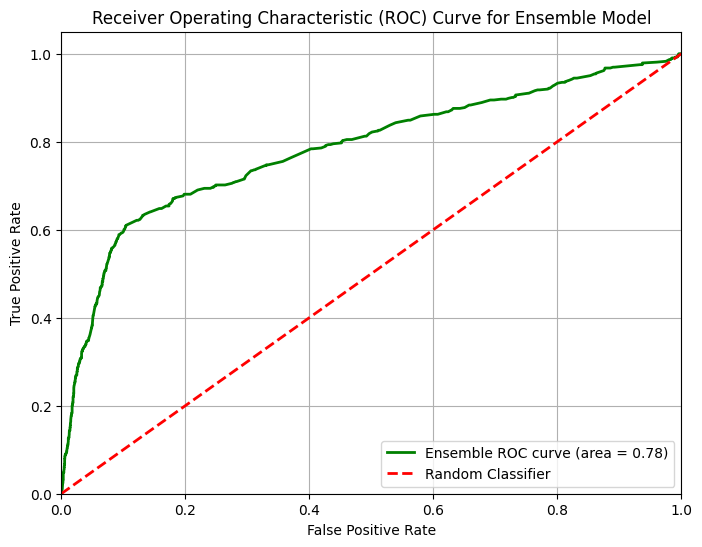


--- Evaluasi Precision dan Recall Ensemble (Threshold 0.5) ---
              precision    recall  f1-score   support

           0       0.95      0.69      0.80      4061
           1       0.24      0.73      0.36       523

    accuracy                           0.70      4584
   macro avg       0.59      0.71      0.58      4584
weighted avg       0.87      0.70      0.75      4584

Precision for Class 1: 0.2352
Recall for Class 1: 0.7342

--- Analisis Threshold untuk Precision dan Recall (Kelas Positif) ---


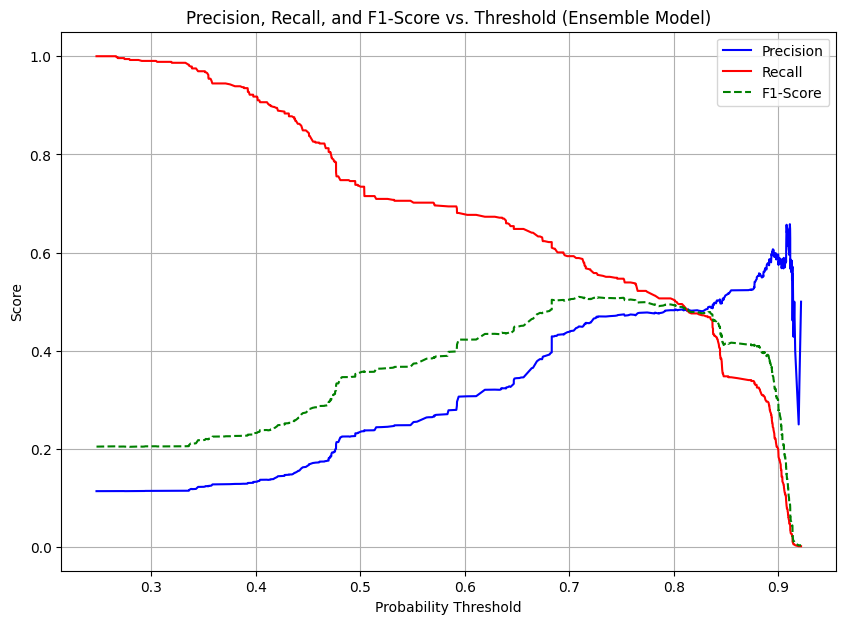

Optimal Threshold (based on F1-score): 0.7262
Precision at optimal F1 threshold: 0.4695
Recall at optimal F1 threshold: 0.5583


In [44]:
if len(estimators_for_ensemble) > 1:
    # Kamu bisa menyesuaikan bobot (weights) di sini jika diinginkan.
    # Misalnya, bobot berdasarkan Test AUC Score:
    # weights = results_df_individual.set_index('Model').loc[[est[0].replace('_', ' ') for est in estimators_for_ensemble], 'Test AUC Score'].values
    # weights = [w / sum(weights) for w in weights] # Normalisasi bobot
    # Untuk awal, bisa coba tanpa bobot eksplisit (rata-rata)

    ensemble_final_model = VotingClassifier(estimators=estimators_for_ensemble, voting='soft', n_jobs=-1)

    print(f"Melatih VotingClassifier dengan {len(estimators_for_ensemble)} model dasar.")
    ensemble_final_model.fit(X_train, y_train) # Fit ensemble model pada data training
    print("VotingClassifier berhasil dilatih.")

    # Evaluasi Ensemble pada test set
    y_pred_proba_ensemble = ensemble_final_model.predict_proba(X_test)[:, 1]
    auc_ensemble = roc_auc_score(y_test, y_pred_proba_ensemble)
    print(f"\nSkor AUC Ensemble (VotingClassifier) pada Test Set: {auc_ensemble:.4f}")

    # Visualisasi Kurva ROC untuk Ensemble
    fpr_ensemble, tpr_ensemble, thresholds_ensemble = roc_curve(y_test, y_pred_proba_ensemble)
    plt.figure(figsize=(8, 6))
    plt.plot(fpr_ensemble, tpr_ensemble, color='green', lw=2, label=f'Ensemble ROC curve (area = {auc_ensemble:.2f})')
    plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--', label='Random Classifier')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve for Ensemble Model')
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()

    # Evaluasi Precision dan Recall untuk Ensemble (dengan threshold 0.5)
    print("\n--- Evaluasi Precision dan Recall Ensemble (Threshold 0.5) ---")
    y_pred_ensemble_binary = (y_pred_proba_ensemble >= 0.5).astype(int)
    print(classification_report(y_test, y_pred_ensemble_binary))
    print(f"Precision for Class 1: {precision_score(y_test, y_pred_ensemble_binary):.4f}")
    print(f"Recall for Class 1: {recall_score(y_test, y_pred_ensemble_binary):.4f}")

    # Analisis Threshold untuk Precision dan Recall
    print("\n--- Analisis Threshold untuk Precision dan Recall (Kelas Positif) ---")
    precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba_ensemble)
    f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8) # Add small epsilon to avoid division by zero

    plt.figure(figsize=(10, 7))
    plt.plot(thresholds, precision[:-1], label='Precision', color='blue')
    plt.plot(thresholds, recall[:-1], label='Recall', color='red')
    plt.plot(thresholds, f1_scores[:-1], label='F1-Score', color='green', linestyle='--')
    plt.xlabel('Probability Threshold')
    plt.ylabel('Score')
    plt.title('Precision, Recall, and F1-Score vs. Threshold (Ensemble Model)')
    plt.legend()
    plt.grid(True)
    plt.show()

    # Find threshold for optimal F1-score (or other balance)
    optimal_f1_threshold = thresholds[np.argmax(f1_scores)]
    print(f"Optimal Threshold (based on F1-score): {optimal_f1_threshold:.4f}")
    print(f"Precision at optimal F1 threshold: {precision_score(y_test, (y_pred_proba_ensemble >= optimal_f1_threshold).astype(int)):.4f}")
    print(f"Recall at optimal F1 threshold: {recall_score(y_test, (y_pred_proba_ensemble >= optimal_f1_threshold).astype(int)):.4f}")

    # Set final_model to the ensemble model
    final_model_for_prediction = ensemble_final_model
else:
    print("\nTidak dapat membuat VotingClassifier karena kurang dari 2 model dasar yang tersedia.")
    print("Menggunakan model terbaik dari hasil tuning individual sebagai final_model.")
    best_single_model_name = results_df_individual.sort_values(by='Test AUC Score', ascending=False).iloc[0]['Model']
    final_model_for_prediction = best_individual_models[best_single_model_name]
    print(f"Model yang digunakan untuk prediksi: {best_single_model_name}")



# Prediksi & Evaluasi (ROC AUC)

In [45]:
# Evaluasi Ensemble pada test set
y_pred_proba_ensemble = ensemble_final_model.predict_proba(X_test)[:, 1]
auc_ensemble = roc_auc_score(y_test, y_pred_proba_ensemble
)
print(f"\nSkor AUC Ensemble (VotingClassifier) pada Test Set: {auc_ensemble:.4f}")


Skor AUC Ensemble (VotingClassifier) pada Test Set: 0.7837


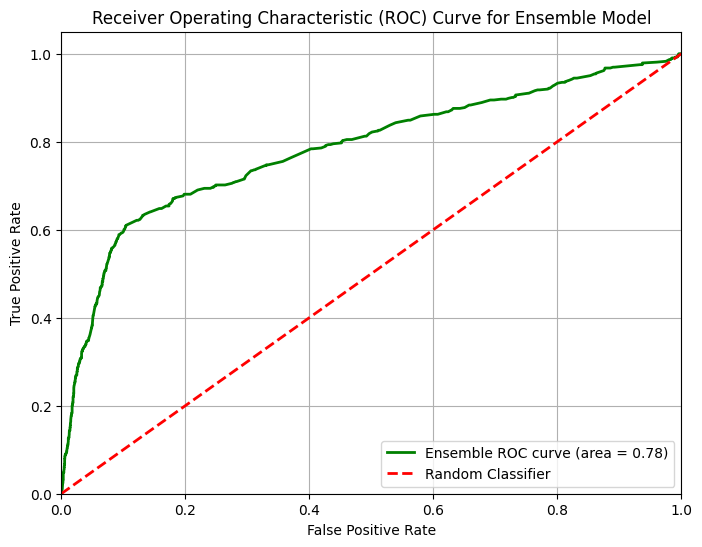

In [46]:
# Visualisasi Kurva ROC untuk Ensemble
fpr_ensemble, tpr_ensemble, thresholds_ensemble = roc_curve(y_test, y_pred_proba_ensemble)
plt.figure(figsize=(8, 6))
plt.plot(fpr_ensemble, tpr_ensemble, color='green', lw=2, label=f'Ensemble ROC curve (area = {auc_ensemble:.2f})')
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for Ensemble Model')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

In [47]:
# Evaluasi Precision dan Recall untuk Ensemble (dengan threshold 0.5)
print("\n--- Evaluasi Precision dan Recall Ensemble (Threshold 0.5) ---")
y_pred_ensemble_binary = (y_pred_proba_ensemble >= 0.5).astype(int)
print(classification_report(y_test, y_pred_ensemble_binary))
print(f"Precision for Class 1: {precision_score(y_test, y_pred_ensemble_binary):.4f}")
print(f"Recall for Class 1: {recall_score(y_test, y_pred_ensemble_binary):.4f}")


--- Evaluasi Precision dan Recall Ensemble (Threshold 0.5) ---
              precision    recall  f1-score   support

           0       0.95      0.69      0.80      4061
           1       0.24      0.73      0.36       523

    accuracy                           0.70      4584
   macro avg       0.59      0.71      0.58      4584
weighted avg       0.87      0.70      0.75      4584

Precision for Class 1: 0.2352
Recall for Class 1: 0.7342


In [48]:
# Analisis Threshold untuk Precision dan Recall
print("\n--- Analisis Threshold untuk Precision dan Recall (Kelas Positif) ---")
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba_ensemble)
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8) # Add small epsilon to avoid division by zero


--- Analisis Threshold untuk Precision dan Recall (Kelas Positif) ---


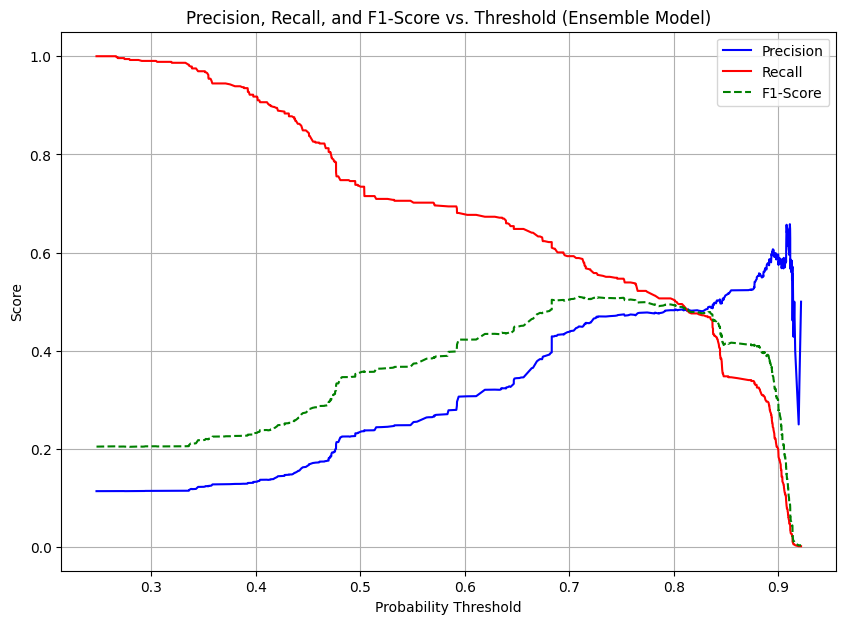

In [49]:
plt.figure(figsize=(10, 7))
plt.plot(thresholds, precision[:-1], label='Precision', color='blue')
plt.plot(thresholds, recall[:-1], label='Recall', color='red')
plt.plot(thresholds, f1_scores[:-1], label='F1-Score', color='green', linestyle='--')
plt.xlabel('Probability Threshold')
plt.ylabel('Score')
plt.title('Precision, Recall, and F1-Score vs. Threshold (Ensemble Model)')
plt.legend()
plt.grid(True)
plt.show()

In [50]:
# Find threshold for optimal F1-score (or other balance)
optimal_f1_threshold = thresholds[np.argmax(f1_scores)]
print(f"Optimal Threshold (based on F1-score): {optimal_f1_threshold:.4f}")
print(f"Precision at optimal F1 threshold: {precision_score(y_test, (y_pred_proba_ensemble >= optimal_f1_threshold).astype(int)):.4f}")
print(f"Recall at optimal F1 threshold: {recall_score(y_test, (y_pred_proba_ensemble >= optimal_f1_threshold).astype(int)):.4f}")

Optimal Threshold (based on F1-score): 0.7262
Precision at optimal F1 threshold: 0.4695
Recall at optimal F1 threshold: 0.5583


In [51]:
# Set final_model to the ensemble model
final_model_for_prediction = ensemble_final_model

In [52]:
# simpan model terbaik untuk prediksi di masa depan
import joblib
joblib.dump(final_model_for_prediction, 'final_model_for_prediction_pacaran_version.pkl')

['final_model_for_prediction_pacaran_version.pkl']

# Prediksi Proba pake Data Validasi

In [53]:
customer_numbers_validation = df_validation['customer_number']
X_validation = df_validation.drop(columns=['customer_number'])

X_validation_processed = X_validation.copy()

In [54]:
# Gunakan final_model_for_prediction (yang bisa berupa ensemble atau model tunggal terbaik)
validation_probabilities = final_model_for_prediction.predict_proba(X_validation_processed)[:, 1]
print("Prediksi probabilitas berhasil dilakukan.")
print(f"Jumlah prediksi probabilitas: {len(validation_probabilities)}")
print(f"Contoh 10 probabilitas pertama: {validation_probabilities[:10]}")

Prediksi probabilitas berhasil dilakukan.
Jumlah prediksi probabilitas: 5729
Contoh 10 probabilitas pertama: [0.47597486 0.41949488 0.35165725 0.3429407  0.58356333 0.33623708
 0.41710622 0.38901376 0.78621615 0.47918936]


# Buat Submission

In [55]:
submission_df = pd.DataFrame({
    'customer_number': customer_numbers_validation,
    'predicted_probability': validation_probabilities
})

print("DataFrame submission berhasil dibuat:")
print(submission_df.head())

DataFrame submission berhasil dibuat:
   customer_number  predicted_probability
0           445420               0.475975
1           585604               0.419495
2           888824               0.351657
3           816820               0.342941
4           542716               0.583563


In [56]:
thePowerofPacaran = 'thePowerofPacaran.csv'
submission_df.to_csv(thePowerofPacaran, index=False)
print(f"\nHasil prediksi disimpan ke file: {thePowerofPacaran}")


Hasil prediksi disimpan ke file: thePowerofPacaran.csv
